In [1]:
from stl import mesh

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits import mplot3d

#
from axial_fan_design import AxialFanDesign

In [2]:
# Define design parameters
rhub = 0.015       # Hub radius (m) - 15mm
rcas = 0.040       # Casing radius (m) - 40mm
Cx = 0.015         # Axial chord (m) - 15mm
Nblade = 7         # Number of blades
Beta_1m = 52.8       # RELATIVE inlet angle at mean (degrees)
vort_exp = -1      # Free vortex (applies to absolute frame)
rpm = 1500         # Rotational speed
DeHaller = 0.75    # De Haller number W2/W1 at midspan

# Create fan design object
fan = AxialFanDesign(rhub, rcas, Cx, Nblade, Beta_1m, vort_exp, rpm, DeHaller)

# Calculate design
des_params = fan.calculate_design(n_points=50)

0.015 -0.007012873355382283 0.015


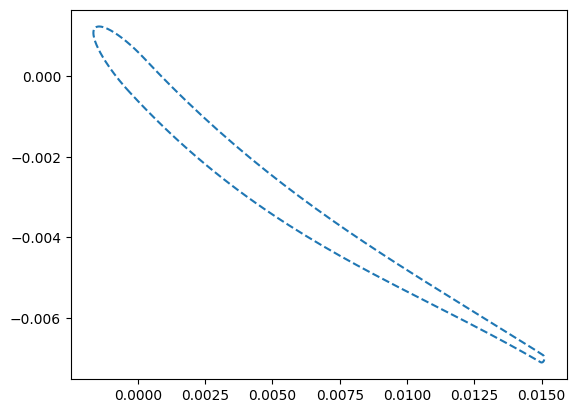

-35.70139538488399 -22.150845339523663


In [3]:
deltas = np.linspace(-np.pi/2, np.pi/2, 100)
i=0
cx = des_params['C_true'][i]*np.cos(np.radians(des_params['stagger'][i]))

a = 0
a2 = cx
b= 0
true_chords = np.arange(0, cx+0.001, 0.001)
stag = true_chords*np.arctan(np.radians(des_params['stagger'][i]))+b
b2 = stag[-1]
R1_major = 0.002
R1_minor = 0.0005
R2 = 0.0001
beta1 = np.radians(des_params['Beta_1'][i])
beta2 = np.radians(des_params['Beta_2'][i])

# Local coordinates for a half-ellipse centered at (0,0)
# We use deltas from -pi/2 to pi/2 to get the front "nose"
x_local = -R1_major * np.cos(deltas)
y_local =  R1_minor * np.sin(deltas)
# Rotation Matrix to align with beta1
# This rotates the ellipse so its major axis points along the blade angle
x_rot = x_local * np.cos(beta1) - y_local * np.sin(beta1)
y_rot = x_local * np.sin(beta1) + y_local * np.cos(beta1)

x = a+x_rot
y = b+y_rot

# half-circle for the tL at (0,0)
x_local2 = R2 * np.cos(deltas)
y_local2 = R2 * np.sin(deltas)

# # rotate to align with beta2
x2_rot = x_local2 * np.cos(beta2) - y_local2 * np.sin(beta2)
y2_rot = x_local2 * np.sin(beta2) + y_local2 * np.cos(beta2)

x2 = a2+x2_rot
y2 = b2+y2_rot
print(a2,b2, true_chords[-1])

# --- 1. SUCTION SIDE (Upper Bridge) ---
# Connects LE Top (index -1) to TE Top (index -1)

# P0: End of LE, P3: End of TE
P0 = np.array([x[-1], y[-1]])
P3 = np.array([x2[-1], y2[-1]])

# Calculate Slopes
# Slope leaving LE (using last 2 points)
slope_start = (y[-1] - y[-2]) / (x[-1] - x[-2])
# Slope entering TE (using last 2 points of TE to match direction)
slope_end = (y2[-1] - y2[-2]) / (x2[-1] - x2[-2])

# Calculate Control Points (P1, P2)
dist_x = P3[0] - P0[0]

# P1: 1/3 of the way, following slope_start
P1_x = P0[0] + dist_x / 3
P1_y = P0[1] + slope_start * (P1_x - P0[0])
P1 = np.array([P1_x, P1_y])

# P2: 2/3 of the way, aligning with slope_end (coming backwards from P3)
P2_x = P3[0] - dist_x / 3
P2_y = P3[1] + slope_end * (P2_x - P3[0])
P2 = np.array([P2_x, P2_y])

# Generate Cubic Bézier
t = np.linspace(0, 1, 50)[:, None]
bridge_bezier = (1-t)**3 * P0 + 3*(1-t)**2*t * P1 + 3*(1-t)*t**2 * P2 + t**3 * P3


# --- 2. PRESSURE SIDE (Lower Bridge) ---
# Connects LE Bottom (index 0) to TE Bottom (index 0)

# P20: Start of LE, P23: Start of TE
P20 = np.array([x[0], y[0]])
P23 = np.array([x2[0], y2[0]])

# Calculate Slopes
# Slope leaving LE (vector pointing away from index 1 towards 0)
slope_start2 = (y[0] - y[1]) / (x[0] - x[1])

# Slope entering TE (vector pointing from 0 towards 1)
# We want the bridge to land smoothly into the start of x2
slope_end2 = (y2[1] - y2[0]) / (x2[1] - x2[0])

# Calculate Control Points (P21, P22)
dist_x_lower = P23[0] - P20[0]

# P21: 1/3 of the way, following slope_start2
P21_x = P20[0] + dist_x_lower / 3
P21_y = P20[1] + slope_start2 * (P21_x - P20[0])
P21 = np.array([P21_x, P21_y])

# P22: 2/3 of the way, aligning with slope_end2
P22_x = P23[0] - dist_x_lower / 3
P22_y = P23[1] + slope_end2 * (P22_x - P23[0])
P22 = np.array([P22_x, P22_y])

# Generate Cubic Bézier
bezier2 = (1-t)**3 * P20 + 3*(1-t)**2*t * P21 + 3*(1-t)*t**2 * P22 + t**3 * P23


# --- 3. CONCATENATE ---
# Note: Ensure x2 is flipped so the loop is continuous
# Sequence: LE Bottom->Top, Suction Bridge, TE Top->Bottom, Pressure Bridge
section_x = np.concatenate([x, bridge_bezier[:, 0], np.flip(x2), np.flip(bezier2[:, 0])])
section_y = np.concatenate([y, bridge_bezier[:, 1], np.flip(y2), np.flip(bezier2[:, 1])])


fig, ax = plt.subplots()


# ax.plot(true_chords, stag)
# ax.plot(bridge_bezier[:, 0], bridge_bezier[:, 1], 'r:')
# ax.plot(bezier2[:, 0], bezier2[:, 1], 'r:')
# ax.scatter(section_x,section_y, linestyle='--', label="blade section",c=np.arange(len(section_x)), cmap='viridis')
ax.plot(section_x,section_y, linestyle='--', label="blade section")
# ax.plot(x, y)
# ax.plot(x2_rot,y2_rot)
# ax.plot(x2,y2)
# ax.legend()
# ax.set_aspect('equal')

# ax.set_xlim(0.0140,0.0160)
# ax.set_ylim(-0.012,-0.010)

plt.show()
print(np.degrees(beta1), np.degrees(beta2))

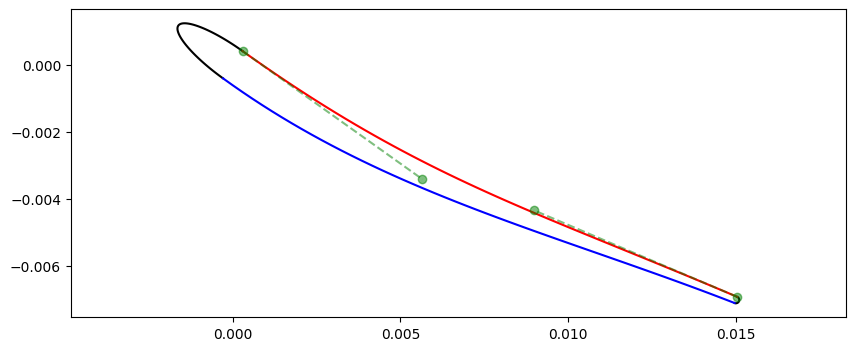

In [4]:
def create_smooth_bridge(p_start, p_end, tan_start_vec, tan_end_vec, fullness=0.35):
    """
    Creates a Cubic Bezier bridge using tangent vectors and a 'fullness' factor.
    fullness: 0.35 is standard for airfoils. Higher = fatter, Lower = flatter.
    """
    # 1. Calculate the straight-line distance (Chord length of the segment)
    chord_len = np.linalg.norm(p_end - p_start)
    
    # 2. Normalize the tangent vectors (make them length 1)
    t1 = tan_start_vec / np.linalg.norm(tan_start_vec)
    t2 = tan_end_vec / np.linalg.norm(tan_end_vec)
    
    # 3. Project Control Points outward by a fraction of the chord length
    # This prevents them from crossing or shooting off to infinity
    control_dist = chord_len * fullness
    
    p1 = p_start + t1 * control_dist
    p2 = p_end + t2 * control_dist # Note: t2 should point BACKWARDS from p_end
    
    # 4. Generate the Curve
    t = np.linspace(0, 1, 50)[:, None]
    curve = (1-t)**3 * p_start + 3*(1-t)**2*t * p1 + 3*(1-t)*t**2 * p2 + t**3 * p_end
    
    return curve, p1, p2

# --- IMPLEMENTATION ---

# 1. SUCTION SIDE (Top)
# Start: Top of LE, End: Top of TE
p_start = np.array([x[-1], y[-1]])
p_end   = np.array([x2[-1], y2[-1]])

# Vector pointing OUT of the LE (Tangent)
v_start = np.array([x[-1] - x[-2], y[-1] - y[-2]])

# Vector pointing INTO the TE (Tangent pointing backwards from TE)
# Note: We want the curve to arrive smoothly, so we look at the vector 
# entering the TE top point.
v_end   = -np.array([x2[-2] - x2[-1], y2[-2] - y2[-1]])

suction_curve, P1, P2 = create_smooth_bridge(p_start, p_end, v_start, v_end, fullness=0.4)


# 2. PRESSURE SIDE (Bottom)
# Start: Bottom of LE, End: Bottom of TE
p_start_low = np.array([x[0], y[0]])
p_end_low   = np.array([x2[0], y2[0]])

# Vector pointing OUT of LE (Bottom)
# Direction: From index 1 to 0 (assuming 0 is the tip of the tail/start)
v_start_low = np.array([x[0] - x[1], y[0] - y[1]])

# Vector pointing INTO TE (Bottom)
v_end_low   = -np.array([x2[1] - x2[0], y2[1] - y2[0]])

pressure_curve, P21, P22 = create_smooth_bridge(p_start_low, p_end_low, v_start_low, v_end_low, fullness=0.35)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(x, y, 'k', label='LE')
ax.plot(x2, y2, 'k', label='TE')
ax.plot(suction_curve[:,0], suction_curve[:,1], 'r-', label='Suction Side')
ax.plot(pressure_curve[:,0], pressure_curve[:,1], 'b-', label='Pressure Side')

# DEBUG: Plot the Control Handles (The "Skeleton")
# If these lines cross, your curve will S-shape!
ax.plot([p_start[0], P1[0]], [p_start[1], P1[1]], 'g--o', alpha=0.5)
ax.plot([p_end[0], P2[0]], [p_end[1], P2[1]], 'g--o', alpha=0.5)

ax.axis('equal')
plt.show()

In [5]:
def blade_section(i):
    deltas = np.linspace(-np.pi/2, np.pi/2, 100)
    cx = des_params['C_true'][i]*np.cos(np.radians(des_params['stagger'][i]))

    a = 0
    a2 = cx
    b= 0
    true_chords = np.arange(0, cx+0.001, 0.001)
    stag = true_chords*np.arctan(np.radians(des_params['stagger'][i]))+b
    b2 = stag[-1]
    R1_major = 0.002
    R1_minor = 0.0005
    R2 = 0.0001
    beta1 = np.radians(des_params['Beta_1'][i])
    beta2 = np.radians(des_params['Beta_2'][i])

    # Local coordinates for a half-ellipse centered at (0,0)
    # We use deltas from -pi/2 to pi/2 to get the front "nose"
    x_local = -R1_major * np.cos(deltas)
    y_local =  R1_minor * np.sin(deltas)
    # Rotation Matrix to align with beta1
    # This rotates the ellipse so its major axis points along the blade angle
    x_rot = x_local * np.cos(beta1) - y_local * np.sin(beta1)
    y_rot = x_local * np.sin(beta1) + y_local * np.cos(beta1)

    x = a+x_rot
    y = b+y_rot

    # half-circle for the tL at (0,0)
    x_local2 = R2 * np.cos(deltas)
    y_local2 = R2 * np.sin(deltas)

    # # rotate to align with beta2
    x2_rot = x_local2 * np.cos(beta2) - y_local2 * np.sin(beta2)
    y2_rot = x_local2 * np.sin(beta2) + y_local2 * np.cos(beta2)

    x2 = a2+x2_rot
    y2 = b2+y2_rot

    # --- 1. SUCTION SIDE (Upper Bridge) ---
    # Connects LE Top (index -1) to TE Top (index -1)

    # P0: End of LE, P3: End of TE
    P0 = np.array([x[-1], y[-1]])
    P3 = np.array([x2[-1], y2[-1]])

    # Calculate Slopes
    # Slope leaving LE (using last 2 points)
    slope_start = (y[-1] - y[-2]) / (x[-1] - x[-2])
    # Slope entering TE (using last 2 points of TE to match direction)
    slope_end = (y2[-1] - y2[-2]) / (x2[-1] - x2[-2])

    # Calculate Control Points (P1, P2)
    dist_x = P3[0] - P0[0]

    # P1: 1/3 of the way, following slope_start
    P1_x = P0[0] + dist_x / 3
    P1_y = P0[1] + slope_start * (P1_x - P0[0])
    P1 = np.array([P1_x, P1_y])

    # P2: 2/3 of the way, aligning with slope_end (coming backwards from P3)
    P2_x = P3[0] - dist_x / 3
    P2_y = P3[1] + slope_end * (P2_x - P3[0])
    P2 = np.array([P2_x, P2_y])

    # Generate Cubic Bézier
    t = np.linspace(0, 1, 50)[:, None]
    bridge_bezier = (1-t)**3 * P0 + 3*(1-t)**2*t * P1 + 3*(1-t)*t**2 * P2 + t**3 * P3


    # --- 2. PRESSURE SIDE (Lower Bridge) ---
    # Connects LE Bottom (index 0) to TE Bottom (index 0)

    # P20: Start of LE, P23: Start of TE
    P20 = np.array([x[0], y[0]])
    P23 = np.array([x2[0], y2[0]])

    # Calculate Slopes
    # Slope leaving LE (vector pointing away from index 1 towards 0)
    slope_start2 = (y[0] - y[1]) / (x[0] - x[1])

    # Slope entering TE (vector pointing from 0 towards 1)
    # We want the bridge to land smoothly into the start of x2
    slope_end2 = (y2[1] - y2[0]) / (x2[1] - x2[0])

    # Calculate Control Points (P21, P22)
    dist_x_lower = P23[0] - P20[0]

    # P21: 1/3 of the way, following slope_start2
    P21_x = P20[0] + dist_x_lower / 3
    P21_y = P20[1] + slope_start2 * (P21_x - P20[0])
    P21 = np.array([P21_x, P21_y])

    # P22: 2/3 of the way, aligning with slope_end2
    P22_x = P23[0] - dist_x_lower / 3
    P22_y = P23[1] + slope_end2 * (P22_x - P23[0])
    P22 = np.array([P22_x, P22_y])

    # Generate Cubic Bézier
    bezier2 = (1-t)**3 * P20 + 3*(1-t)**2*t * P21 + 3*(1-t)*t**2 * P22 + t**3 * P23


    # --- 3. CONCATENATE ---
    # Note: Ensure x2 is flipped so the loop is continuous
    # Sequence: LE Bottom->Top, Suction Bridge, TE Top->Bottom, Pressure Bridge
    section_x = np.concatenate([x, bridge_bezier[:, 0], np.flip(x2), np.flip(bezier2[:, 0])])
    section_y = np.concatenate([y, bridge_bezier[:, 1], np.flip(y2), np.flip(bezier2[:, 1])])
    
    return section_x, section_y

In [6]:
sections = []

for i,r in enumerate(des_params['r']):
    section_x, section_y = blade_section(i)
    sections.append(np.stack([section_x, section_y, np.full_like(section_x, r)], axis=1))

In [7]:
faces = []
n_pts = len(sections[0])
n_sec = len(sections)

for i in range(n_sec - 1):
    for j in range(n_pts - 1):
        # Define 4 corners of a "rectangle" between two radial layers
        p1 = sections[i][j]
        p2 = sections[i][j+1]
        p3 = sections[i+1][j+1]
        p4 = sections[i+1][j]
        
        # Triangle 1
        faces.append([p1, p2, p3])
        # Triangle 2
        faces.append([p1, p3, p4])

# Convert to numpy array for STL
faces_array = np.array(faces)

In [8]:
# Create the mesh object
blade_mesh = mesh.Mesh(np.zeros(faces_array.shape[0], dtype=mesh.Mesh.dtype))
for i, f in enumerate(faces_array):
    blade_mesh.vectors[i] = f

# Save to disk
blade_mesh.save('compressor_blade.stl')

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

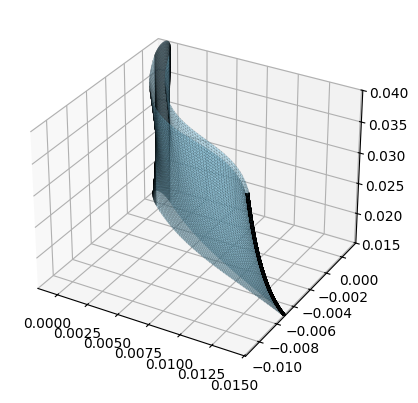

In [10]:
data = np.array(sections)

# Extract individual coordinates for plotting
# X, Y, Z will each be shape (N_radii, N_points)
X = data[:, :, 0]
Y = data[:, :, 1]
Z = data[:, :, 2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Using the 'faces' list we created in the previous step
# (Each face is a [3, 3] array of vertices)
poly3d = Poly3DCollection(faces_array, alpha=0.5, edgecolor='k', linewidths=0.1)
poly3d.set_facecolor('skyblue')

ax.add_collection3d(poly3d)

# Manually set limits since Poly3DCollection doesn't auto-scale well
ax.set_xlim(np.min(X), np.max(X))
ax.set_ylim(np.min(Y), np.max(Y))
ax.set_zlim(np.min(Z), np.max(Z))

plt.show()

In [1]:
from prof_gen import Profile
from stl import mesh

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits import mplot3d

#
from axial_fan_design import AxialFanDesign

In [2]:
rhub = 0.015       # Hub radius (m) - 15mm
rcas = 0.040       # Casing radius (m) - 40mm
rmean = (rhub + rcas) / 2
rpm = 2000
vol_flow_rate = 50 / 60 / 60 # 50 m^3/hr converted to m^3/s
area = np.pi*(rcas**2 - rhub**2)
v_axial = vol_flow_rate / area
u = 2 * np.pi * rmean * rpm / 60
Beta_1m = np.degrees(np.arctan(u/v_axial))
print(Beta_1m, u, v_axial, vol_flow_rate, area)

60.827847737270254 5.759586531581287 3.215251375593845 0.01388888888888889 0.004319689898685966


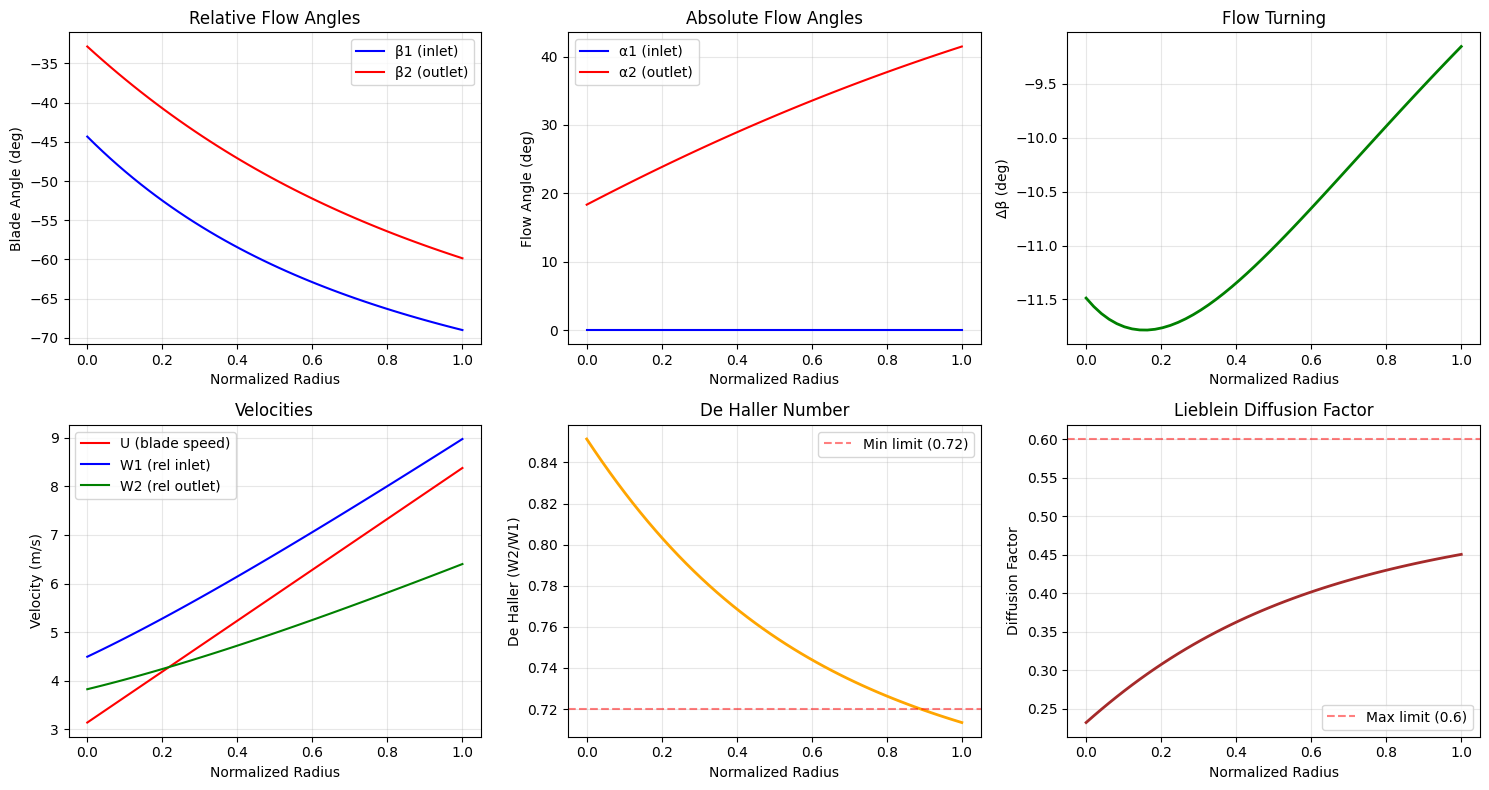

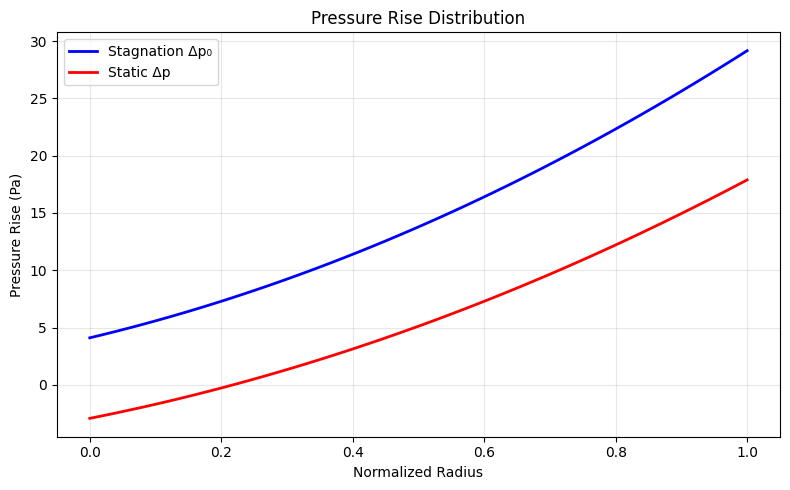

In [3]:
# Define design parameters

Cx = 0.015         # Axial chord (m) - 15mm
Nblade = 7         # Number of blades
# Beta_1m = 52.8       # RELATIVE inlet angle at mean (degrees)
vort_exp = -1      # Free vortex (applies to absolute frame)
# rpm = 1500         # Rotational speed
DeHaller = 0.75    # De Haller number W2/W1 at midspan

# Create fan design object
fan = AxialFanDesign(rhub, rcas, Cx, Nblade, Beta_1m, vort_exp, rpm, DeHaller)

# Calculate design
des_params = fan.calculate_design(n_points=50)
fan.plot_radial_distributions()

In [69]:
sections = []
for i, r in enumerate(des_params['r']):
    XU, YU, XL, YL, Xall, Yall = Profile(
        X1 = des_params['Beta_1'][i],
        X2 = des_params['Beta_2'][i],
        TKTE = 0.0005,
        Cx = des_params['C_true'][i]*np.cos(np.radians(des_params['stagger'][i])),
    )
    if i == 0:
        j = None
        n = None

        for k, element in enumerate(XU):
            if np.isclose(element, Cx/2, atol = 0.00002):
                j = k
        for m, element in enumerate(XL):
            if np.isclose(element, Cx/2, atol = 0.00002):
                n = m

        if j is None or n is None:
            raise ValueError("Could not find index where XU or XL is approximately half the chord length.")


        y_mid_blade = (YU[j]+YL[n])/2
        
    Yall = Yall - y_mid_blade # Centre blade at y=0 using mid-blade point for rhub
    
    # X is axial, Y is r*theta, Z is radial. 
    # Convert Y,Z to Cartesian for STL
    Z_cart = Xall # Axial becomes Z axis
    theta = Yall/r 
    X_cart = r * np.cos(theta)
    Y_cart = r * np.sin(theta)
    
    
    sections.append(np.stack([X_cart, Y_cart, Z_cart], axis=1))


In [70]:
faces = []
n_pts = len(sections[0])
n_sec = len(sections)

for i in range(n_sec - 1):
    for j in range(n_pts - 1):
        # Define 4 corners of a "rectangle" between two radial layers
        p1 = sections[i][j]
        p2 = sections[i][j+1]
        p3 = sections[i+1][j+1]
        p4 = sections[i+1][j]
        
        # Triangle 1
        faces.append([p1, p2, p3])
        # Triangle 2
        faces.append([p1, p3, p4])
        
# Close surface at hub and casing by making triangles at the first and last radial layers
for i in [0, -1]:
    for j in range(n_pts - 1):
        # Hub (first radial layer)
        if j == 0:
            p1 = sections[i][j-1]
            p2 = sections[i][j]
            p3 = sections[i][j+1]
            faces.append([p1, p2, p3])
            prev_p1 = j-1
            prev_p2 = j
            prev_p3 = j+1
            
        elif prev_p3 - prev_p2 == n_pts -1:
            break
        elif j%2 == 0:
            # Even
            p1 = sections[i][prev_p1]
            p2 = sections[i][prev_p3]
            p3 = sections[i][prev_p3+1]
            faces.append([p1, p2, p3])
            prev_p1 = prev_p1
            prev_p2 = prev_p3
            prev_p3 = prev_p3+1
        elif j%2 == 1:
            # Odd
            p1 = sections[i][prev_p1-1]
            p2 = sections[i][prev_p1]
            p3 = sections[i][prev_p3]
            faces.append([p1, p2, p3])
            prev_p1 = prev_p1-1
            prev_p2 = prev_p1
            prev_p3 = prev_p3

# Convert to numpy array for STL
faces_array = np.array(faces)
# Rotate blade section around the X-axis to create the full fan
faces = []
rotation_angle_x = 180
rotation_matrix_x = np.array([[1, 0, 0],
                            [0, np.cos(np.radians(rotation_angle_x)), -np.sin(np.radians(rotation_angle_x))],
                            [0, np.sin(np.radians(rotation_angle_x)), np.cos(np.radians(rotation_angle_x))],
                            ])
for face in faces_array:
    rotated_face = np.matmul(rotation_matrix_x, face.T).T
    faces.append(rotated_face)
    
faces_array = np.array(faces)

# Rotate the blade section around the Z-axis to create the full fan
all_faces = []
for i in range(Nblade):
    rotation_angle = i * (360 / Nblade)
    rotation_matrix = np.array([[np.cos(np.radians(rotation_angle)), -np.sin(np.radians(rotation_angle)), 0],
                                [np.sin(np.radians(rotation_angle)), np.cos(np.radians(rotation_angle)), 0],
                                [0, 0, 1]])
    for face in faces_array:
        rotated_face = np.matmul(rotation_matrix, face.T).T
        all_faces.append(rotated_face)
        
all_faces = np.array(all_faces)

In [71]:
hub_file = r"MarketDesign1 - ChrisEyeball.stl"
hub_mesh = mesh.Mesh.from_file(hub_file)

In [72]:
# Create the mesh object
blade_mesh = mesh.Mesh(np.zeros(all_faces.shape[0]+hub_mesh.vectors.shape[0], dtype=mesh.Mesh.dtype))

for i, f in enumerate(all_faces):
    blade_mesh.vectors[i] = f


# # Translate hub to align with blade section
diff = blade_mesh.z.min() - hub_mesh.z.min() - 0.002 # Clearance
copy_hub_mesh = mesh.Mesh(hub_mesh.data.copy())
copy_hub_mesh.points[:, (2,5,8)] += diff

for j, g in enumerate(copy_hub_mesh.vectors):
    blade_mesh.vectors[i+j] = g
    
# Save to disk
blade_mesh.save('compressor_blade.stl')

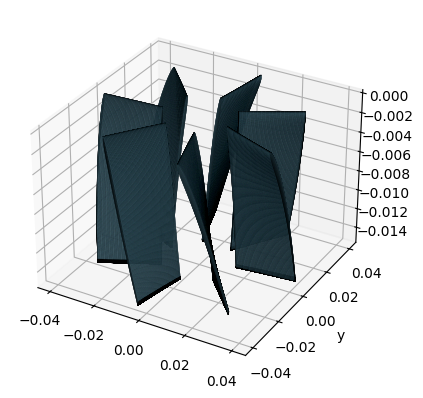

In [73]:
# data = np.array(sections)

# # Extract individual coordinates for plotting
# # X, Y, Z will each be shape (N_radii, N_points)
# X = data[:, :, 0]
# Y = data[:, :, 1]
# Z = data[:, :, 2]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Using the 'faces' list we created in the previous step
# (Each face is a [3, 3] array of vertices)
poly3d = Poly3DCollection(all_faces, alpha=0.5, edgecolor='k', linewidths=0.1)
poly3d.set_facecolor('skyblue')

ax.add_collection3d(poly3d)

# Manually set limits since Poly3DCollection doesn't auto-scale well
# ax.set_xlim(np.min(X), np.max(X))
# ax.set_ylim(np.min(Y), np.max(Y))
# ax.set_zlim(np.min(Z), np.max(Z))

ax.set_ylabel('y')

plt.show()

In [2]:
section_file = r'throughflow_solver\DOE2_rotor_only_fan_curtis_blade_sections.npz'
data = np.load(section_file, allow_pickle=True)
sections = data['sections'].item()['R1']
print(len(sections))
print(sections[-1].keys())

20
dict_keys(['x', 'r', 'theta', 'height', 'r_metres', 'P2C', 'loss', 'DFfrac', 'X_curtis', 'Z_curtis'])


In [3]:
test_section = sections[-1]
def convert_to_cartestian(test_section):
    Z_cart = test_section['x'] # Axial becomes Z axis
    theta = test_section['theta']
    r = test_section['r']
    X_cart = r * np.cos(theta)
    Y_cart = r * np.sin(theta)
    
    return X_cart, Y_cart, Z_cart


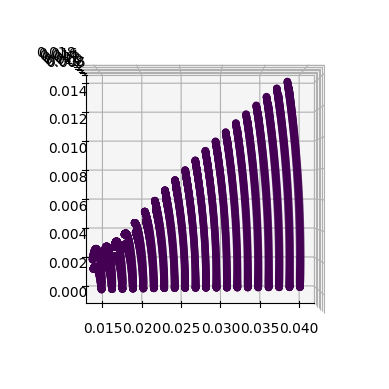

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i, section in enumerate(sections):
    X_cart, Y_cart, Z_cart = convert_to_cartestian(section)
    ax.scatter(X_cart, Y_cart, Z_cart, c=np.ones_like(X_cart)*i*0.01, cmap='viridis')
ax.view_init(elev=90, azim=-90, roll=0)
plt.show()

In [8]:
from DOE2_rotor_only_fan_generator import create_doe2_rotor_only_fan_parametric

In [9]:
create_doe2_rotor_only_fan_parametric(
        rhub=0.015,
        rtip=0.040,
        RPM=3000.0,
        mdot=0.05,               # 0.05 kg/s (further reduced for better blade effect)
        DHmid=0.85,               # De Haller = 0.85 (diffusion)
        INC=0.0,                 # No incidence
        Vexp=-1.0,               # Free vortex (rVt=const)
        num_streamlines=20,
        rotor_blades=7,
        num_internal_stations=5,
        enable_curtis=True,      # ENABLE CURTIS OPTIMIZATION
        filename="DOE2_rotor_only_fan_curtis.dat"
    )

=== PARAMETRIC ROTOR-ONLY FAN ===
Input Parameters:
  Hub radius: 15.0 mm, Tip radius: 40.0 mm, Span: 25.0 mm
  Speed: 3000 rpm, Mass flow: 0.050 kg/s
  De Haller (DHmid): 0.850, Incidence: 0.0, Vortex exponent: -1.00
Calculated Flow Properties:
  Absolute inlet axial velocity: 9.44 m/s
  Blade speed at midspan: 8.64 m/s
  Relative inlet velocity: 12.80 m/s
  Relative exit velocity: 10.88 m/s
  Absolute exit tangential velocity (mid): 3.24 m/s
  Absolute Vtheta:  Hub 5.937 m/s, Mid 3.238 m/s, Tip 2.226 m/s
  r*Vtheta:         Hub 0.08905, Mid 0.08905, Tip 0.08905
  Absolute exit angles: Hub 32.15, Mid 18.92, Tip 13.26
  **RELATIVE exit angles (for SLEQ): Hub 7.39, Mid -29.76, Tip -47.59**
  Vortex law radial points: 20 (exact at each streamline)
  Inlet incidence angle (absolute): 0.00
  Parallel annulus: Hub 15.0mm to Tip 40.0mm (span 25.0mm)
  Fixed dimensions: inlet(6mm) + rotor(12mm) + exit(12mm) = 30mm total
  Rotor inlet: 0.0° absolute (axial)
  Rotor outlet: -29.8° absolute (uni

'DOE2 PARAMETRIC ROTOR-ONLY FAN\n21  20  20  0  0  0  0  12  8  1  0  0   1   0   0   0    0\n   0     0.000000      0.000000      0.015000      0.040000      1.0       0.0\n   0     0.001200      0.001200      0.015000      0.040000      1.0       0.0\n   0     0.002400      0.002400      0.015000      0.040000      1.0       0.0\n   0     0.003600      0.003600      0.015000      0.040000      1.0       0.0\n   0     0.004800      0.004800      0.015000      0.040000      1.0       0.0\n  -1     0.006000      0.006000      0.015000      0.040000      1.0       0.0\n  -2     0.008000      0.008000      0.015000      0.040000      1.0       0.0\n  -2     0.010000      0.010000      0.015000      0.040000      1.0       0.0\n  -2     0.012000      0.012000      0.015000      0.040000      1.0       0.0\n  -2     0.014000      0.014000      0.015000      0.040000      1.0       0.0\n  -2     0.016000      0.016000      0.015000      0.040000      1.0       0.0\n  -3     0.018000      0.0